## Predict likely failure windows for an industrial air compressor

This notebook moves from a small tabular failure dataset to a time series from one real compressor. Instead of ranking many machines, it ranks recent time windows from one asset to estimate which periods look most likely to lead to a reported failure soon.

The data come from the MetroPT 3 AirCompressor Sensor dataset, a time ordered stream of sensor readings from one industrial air compressor.

## Goal

Predict which recent time windows are most likely to be followed by a reported compressor failure within the next 24 hours.

## What to picture

Think of one compressor being watched over time. Each row is a moment in that timeline. This notebook groups recent sensor behavior into windows and scores each window for near term failure risk.

## What matters up front

- Only a small number of reported failure episodes are available.
- The target used here is heuristic.
- A positive window means a reported failure begins within the next 24 hours.
- Windows during active failure are removed from training because they reflect failure in progress, not advance warning.

This is a practical early warning ranking notebook for one industrial air compressor, not a full maintenance optimization system.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')


## Run settings

These values define the operating frame.

Some are policy inputs, not facts learned from the data. Review capacity, precision floor, and cost assumptions are business choices used to translate model output into action.


In [2]:

random_seed = 42
window_size = '30min'
lookahead_hours = 24

review_capacity = 24
review_capacity_options = [12, 24, 48, 72]
expedite_slots = 8
minimum_precision_for_high_risk = 0.20

review_cost_per_alert = 1.0
missed_failure_loss = 20.0

source_path = Path('/kaggle/input/datasets/patimejia/metropt3-aircompressor-time-series/MetroPT3(AirCompressor).csv')
if not source_path.exists():
    raise FileNotFoundError('Could not find the MetroPT 3 source file.')

print(f'Source path: {source_path}')


Source path: /kaggle/input/datasets/patimejia/metropt3-aircompressor-time-series/MetroPT3(AirCompressor).csv



## Load the source and define the reported failure periods

The source file is a time series from one compressor.

The company reported four air leak failure periods. They are used here to create a practical early warning target. That target is not native to the source file. It is a modeling choice.


In [3]:

source_data = pd.read_csv(source_path, parse_dates=['timestamp'])
source_data = source_data.drop(columns=['Unnamed: 0'], errors='ignore')
source_data = source_data.sort_values('timestamp').reset_index(drop=True)

failure_periods = pd.DataFrame({
    'failure_id': ['F1', 'F2', 'F3', 'F4'],
    'start_time': pd.to_datetime([
        '2020-04-18 00:00:00',
        '2020-05-29 23:30:00',
        '2020-06-05 10:00:00',
        '2020-07-15 14:30:00',
    ]),
    'end_time': pd.to_datetime([
        '2020-04-18 23:59:00',
        '2020-05-30 06:00:00',
        '2020-06-07 14:30:00',
        '2020-07-15 19:00:00',
    ]),
})

print(f'Rows: {len(source_data):,}')
print(f'Columns: {source_data.shape[1]}')
print(f'Time span: {source_data["timestamp"].min()} to {source_data["timestamp"].max()}')
print(f'Reported failures: {len(failure_periods)}')

source_data.head()


Rows: 1,516,948
Columns: 16
Time span: 2020-02-01 00:00:00 to 2020-09-01 03:59:50
Reported failures: 4


,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.040,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000
1,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.040,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000
2,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.042,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000
3,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.040,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000
4,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.040,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000



## Audit the raw source

Before modeling, confirm the shape of the source, sensor coverage, and whether missing values or duplicates are large enough to distort the setup.


In [4]:

raw_data_quality = pd.DataFrame({
    'dtype': source_data.dtypes.astype(str),
    'missing_count': source_data.isna().sum(),
    'missing_pct': source_data.isna().mean().mul(100).round(3),
    'unique_values': source_data.nunique(),
})

print(f'Duplicate rows: {source_data.duplicated().sum():,}')
raw_data_quality


Duplicate rows: 0


,dtype,missing_count,missing_pct,unique_values
timestamp,datetime64[ns],0,0.000,1516948
TP2,float64,0,0.000,5257
TP3,float64,0,0.000,3683
H1,float64,0,0.000,2665
DV_pressure,float64,0,0.000,2257
Reservoirs,float64,0,0.000,3682
Oil_temperature,float64,0,0.000,2462
Motor_current,float64,0,0.000,1809
COMP,float64,0,0.000,2
DV_eletric,float64,0,0.000,2



## Build a modeling table from time windows

The source is too granular for direct queueing, so the notebook aggregates it into 30 minute windows.

Each row in the modeling table is one operating window. The model does not predict exact failure timing. It estimates whether a reported failure starts within the next 24 hours.

That target is a heuristic early warning label, not a ground truth field from the source data.


In [5]:

analog_signals = [
    'TP2',
    'TP3',
    'H1',
    'DV_pressure',
    'Reservoirs',
    'Oil_temperature',
    'Motor_current',
]

digital_signals = [
    'COMP',
    'DV_eletric',
    'Towers',
    'MPG',
    'LPS',
    'Pressure_switch',
    'Oil_level',
    'Caudal_impulses',
]

aggregation_map = {
    **{signal: ['mean', 'std', 'min', 'max', 'last'] for signal in analog_signals},
    **{signal: ['mean', 'last'] for signal in digital_signals},
}

window_table = source_data.set_index('timestamp').resample(window_size).agg(aggregation_map)
window_table.columns = ['_'.join(column_name) for column_name in window_table.columns]
window_table = window_table.reset_index().rename(columns={'timestamp': 'window_start'})
window_table['window_end'] = window_table['window_start'] + pd.Timedelta(window_size)

row_count_by_window = (
    source_data.set_index('timestamp')
    .resample(window_size)
    .size()
    .reset_index(name='rows_in_window')
)

window_table = window_table.merge(
    row_count_by_window.rename(columns={'timestamp': 'window_start'}),
    on='window_start',
    how='left',
)

window_table = window_table.loc[window_table['rows_in_window'] > 0].copy()

trend_source_columns = [
    'TP2_mean',
    'TP3_mean',
    'DV_pressure_mean',
    'Reservoirs_mean',
    'Oil_temperature_mean',
    'Motor_current_mean',
    'COMP_mean',
    'DV_eletric_mean',
    'LPS_mean',
]

for column_name in trend_source_columns:
    window_table[f'{column_name}_change_1'] = window_table[column_name].diff(1)
    window_table[f'{column_name}_change_6'] = window_table[column_name].diff(6)

window_table['during_failure'] = False
for _, failure_row in failure_periods.iterrows():
    overlap_mask = (
        (window_table['window_start'] < failure_row['end_time'])
        & (window_table['window_end'] > failure_row['start_time'])
    )
    window_table.loc[overlap_mask, 'during_failure'] = True

failure_start_array = failure_periods['start_time'].sort_values().to_numpy(dtype='datetime64[ns]')
window_end_array = window_table['window_end'].to_numpy(dtype='datetime64[ns]')
next_failure_position = np.searchsorted(failure_start_array, window_end_array, side='left')
next_failure_start = np.full(len(window_table), np.datetime64('NaT'), dtype='datetime64[ns]')
valid_next_failure_mask = next_failure_position < len(failure_start_array)
next_failure_start[valid_next_failure_mask] = failure_start_array[next_failure_position[valid_next_failure_mask]]

window_table['hours_to_next_failure'] = (
    (next_failure_start - window_end_array) / np.timedelta64(1, 'h')
)

window_table['fail_within_24h'] = (
    (window_table['hours_to_next_failure'] > 0)
    & (window_table['hours_to_next_failure'] <= lookahead_hours)
).astype(int)

modeling_data = window_table.loc[~window_table['during_failure']].copy()
modeling_data['alert_id'] = np.arange(1, len(modeling_data) + 1)

print(f'Modeling rows: {len(modeling_data):,}')
print(f'Positive windows: {int(modeling_data["fail_within_24h"].sum()):,}')
print(f'Positive rate: {modeling_data["fail_within_24h"].mean():.2%}')

modeling_data[['window_start', 'window_end', 'hours_to_next_failure', 'fail_within_24h']].head()


Modeling rows: 8,483
Positive windows: 167
Positive rate: 1.97%


,window_start,window_end,hours_to_next_failure,fail_within_24h
0,2020-02-01 00:00:00,2020-02-01 00:30:00,"1,847.500",0
1,2020-02-01 00:30:00,2020-02-01 01:00:00,"1,847.000",0
2,2020-02-01 01:00:00,2020-02-01 01:30:00,"1,846.500",0
3,2020-02-01 01:30:00,2020-02-01 02:00:00,"1,846.000",0
4,2020-02-01 02:00:00,2020-02-01 02:30:00,"1,845.500",0



## Split by time, not at random

Random split can look too good on a time series problem.

This notebook uses a blocked time split instead.

Train covers the earlier period.
Validation covers the middle period and includes one reported failure episode.
Test covers the later period and includes the last reported failure episode.

That is still not perfect, but it is more credible than shuffling time windows.


In [6]:

train_data = modeling_data.loc[modeling_data['window_end'] < '2020-06-01'].copy()
validation_data = modeling_data.loc[
    (modeling_data['window_end'] >= '2020-06-01')
    & (modeling_data['window_end'] < '2020-06-30')
].copy()
test_data = modeling_data.loc[modeling_data['window_end'] >= '2020-06-30'].copy()

split_summary = pd.DataFrame({
    'split': ['Train', 'Validation', 'Test'],
    'rows': [len(train_data), len(validation_data), len(test_data)],
    'positive_windows': [
        int(train_data['fail_within_24h'].sum()),
        int(validation_data['fail_within_24h'].sum()),
        int(test_data['fail_within_24h'].sum()),
    ],
    'positive_rate': [
        train_data['fail_within_24h'].mean(),
        validation_data['fail_within_24h'].mean(),
        test_data['fail_within_24h'].mean(),
    ],
    'start': [
        train_data['window_start'].min(),
        validation_data['window_start'].min(),
        test_data['window_start'].min(),
    ],
    'end': [
        train_data['window_end'].max(),
        validation_data['window_end'].max(),
        test_data['window_end'].max(),
    ],
})

split_summary


,split,rows,positive_windows,positive_rate,start,end
0,Train,4824,85,0.018,2020-02-01 00:00:00,2020-05-31 23:30:00
1,Validation,1100,48,0.044,2020-05-31 23:30:00,2020-06-29 23:30:00
2,Test,2559,34,0.013,2020-06-29 23:30:00,2020-09-01 04:00:00


## Benchmark a small model set

This notebook keeps the benchmark small but not artificially narrow.

It compares one linear baseline and a few tree based models that fit this kind of nonlinear sensor problem better. If XGBoost is available, it is included as one more candidate. The notebook then keeps only the validation winner so the rest of the workflow stays focused.

In [7]:

target_column = 'fail_within_24h'
identifier_columns = ['alert_id', 'window_start', 'window_end', 'during_failure', 'hours_to_next_failure']
feature_columns = [
    column_name
    for column_name in modeling_data.columns
    if column_name not in identifier_columns + [target_column]
]

X_train = train_data[feature_columns].copy()
y_train = train_data[target_column].astype(int).copy()
X_validation = validation_data[feature_columns].copy()
y_validation = validation_data[target_column].astype(int).copy()
X_test = test_data[feature_columns].copy()
y_test = test_data[target_column].astype(int).copy()

candidate_models = {
    'Logistic Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            max_iter=3000,
            class_weight='balanced',
            random_state=random_seed,
        )),
    ]),
    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(
            n_estimators=200,
            min_samples_leaf=5,
            class_weight='balanced_subsample',
            random_state=random_seed,
            n_jobs=-1,
        )),
    ]),
    'Extra Trees': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', ExtraTreesClassifier(
            n_estimators=250,
            min_samples_leaf=3,
            class_weight='balanced',
            random_state=random_seed,
            n_jobs=-1,
        )),
    ]),
}

try:
    from xgboost import XGBClassifier

    scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

    candidate_models['XGBoost'] = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', XGBClassifier(
            n_estimators=120,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,
            reg_lambda=1.0,
            scale_pos_weight=float(scale_pos_weight),
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=random_seed,
            n_jobs=2,
        )),
    ])
except Exception:
    print('XGBoost not available. Continuing without it.')

benchmark_rows = []
fitted_model_map = {}

for model_name, model_pipeline in candidate_models.items():
    model_pipeline.fit(X_train, y_train)
    fitted_model_map[model_name] = model_pipeline

    validation_probability = model_pipeline.predict_proba(X_validation)[:, 1]

    benchmark_rows.append({
        'model': model_name,
        'validation_average_precision': average_precision_score(y_validation, validation_probability),
        'validation_roc_auc': roc_auc_score(y_validation, validation_probability),
        'validation_brier_score': brier_score_loss(y_validation, validation_probability),
    })

benchmark_table = (
    pd.DataFrame(benchmark_rows)
    .sort_values(
        ['validation_average_precision', 'validation_brier_score', 'validation_roc_auc'],
        ascending=[False, True, False],
    )
    .reset_index(drop=True)
)

benchmark_table


,model,validation_average_precision,validation_roc_auc,validation_brier_score
0,Random Forest,0.134,0.754,0.044
1,XGBoost,0.126,0.819,0.072
2,Extra Trees,0.063,0.630,0.061
3,Logistic Regression,0.033,0.378,0.378


## Keep one validation winner, then test it hard

From this point forward, the notebook keeps one model only.

That is done for clarity, not because the winner is proven stable.

The winner is chosen on validation so the later test period stays untouched until the end. That is methodologically cleaner than tuning on test, but it does not guarantee the rule will generalize.

In this notebook, the later test period is the real check. If the chosen model weakens there, the final queue should be treated as exploratory, not operational.

In [8]:

selected_model_name = benchmark_table.loc[0, 'model']
selected_model = fitted_model_map[selected_model_name]

print(f'Selected model: {selected_model_name}')


Selected model: Random Forest



## Choose the operating high risk cutoff from validation data

The queue needs a cutoff, but the cutoff should come from validation data, not from the test period.

The rule here is simple.
Keep cutoffs that meet the minimum precision floor.
Inside that set, choose the one with the best recall.
If no cutoff meets the floor, keep the best precision then recall available.

This is an operating rule, not a claim of certainty.


In [9]:

validation_probability = selected_model.predict_proba(X_validation)[:, 1]
precision_values, recall_values, cutoff_values = precision_recall_curve(y_validation, validation_probability)

cutoff_table = pd.DataFrame({
    'cutoff': cutoff_values,
    'precision': precision_values[:-1],
    'recall': recall_values[:-1],
})

valid_cutoff_table = cutoff_table.loc[
    cutoff_table['precision'] >= minimum_precision_for_high_risk
].copy()

if valid_cutoff_table.empty:
    selected_cutoff_row = cutoff_table.sort_values(
        ['precision', 'recall', 'cutoff'],
        ascending=[False, False, True],
    ).iloc[0]
else:
    selected_cutoff_row = valid_cutoff_table.sort_values(
        ['recall', 'precision', 'cutoff'],
        ascending=[False, False, True],
    ).iloc[0]

operating_high_risk_cutoff = float(selected_cutoff_row['cutoff'])

cutoff_summary = pd.DataFrame({
    'item': [
        'Selected model',
        'Operating high risk cutoff',
        'Validation precision at cutoff',
        'Validation recall at cutoff',
    ],
    'value': [
        selected_model_name,
        operating_high_risk_cutoff,
        float(selected_cutoff_row['precision']),
        float(selected_cutoff_row['recall']),
    ],
})

cutoff_summary


,item,value
0,Selected model,Random Forest
1,Operating high risk cutoff,0.516
2,Validation precision at cutoff,0.400
3,Validation recall at cutoff,0.042



## Build one ranked alert queue on the test period

Each row below is a time window, not a machine.

The queue sorts later period windows from highest predicted risk to lowest predicted risk. That makes the notebook operationally honest for this source.


In [10]:

test_probability = selected_model.predict_proba(X_test)[:, 1]

risk_queue = test_data[['alert_id', 'window_start', 'window_end', target_column]].copy()
risk_queue = risk_queue.rename(columns={target_column: 'actual_failure_window'})
risk_queue['predicted_failure_probability'] = test_probability
risk_queue = risk_queue.sort_values('predicted_failure_probability', ascending=False).reset_index(drop=True)
risk_queue['queue_rank'] = risk_queue.index + 1
risk_queue['is_high_risk'] = risk_queue['predicted_failure_probability'] >= operating_high_risk_cutoff

high_risk_alert_count = int(risk_queue['is_high_risk'].sum())
high_risk_positive_windows = int(risk_queue.loc[risk_queue['is_high_risk'], 'actual_failure_window'].sum())

print(f'High risk windows in the queue: {high_risk_alert_count}')
print(f'Positive windows inside that pool in the test period: {high_risk_positive_windows}')

risk_queue.head(15)


High risk windows in the queue: 14
Positive windows inside that pool in the test period: 0


,alert_id,window_start,window_end,actual_failure_window,predicted_failure_probability,queue_rank,is_high_risk
0,6701,2020-07-19 12:00:00,2020-07-19 12:30:00,0,0.744,1,True
1,6209,2020-07-05 22:00:00,2020-07-05 22:30:00,0,0.688,2,True
2,6541,2020-07-16 01:00:00,2020-07-16 01:30:00,0,0.678,3,True
3,6208,2020-07-05 21:30:00,2020-07-05 22:00:00,0,0.626,4,True
4,6545,2020-07-16 03:00:00,2020-07-16 03:30:00,0,0.604,5,True
5,6543,2020-07-16 02:00:00,2020-07-16 02:30:00,0,0.589,6,True
6,6211,2020-07-05 23:00:00,2020-07-05 23:30:00,0,0.586,7,True
7,6102,2020-07-03 16:30:00,2020-07-03 17:00:00,0,0.573,8,True
8,6633,2020-07-18 02:00:00,2020-07-18 02:30:00,0,0.557,9,True
9,6630,2020-07-18 00:30:00,2020-07-18 01:00:00,0,0.533,10,True



## Test the locked operating rule once on unseen later data

These metrics show how the locked validation rule behaves on the later period.

If they weaken, that matters. This notebook should not hide generalization risk.


In [11]:

test_predicted_high_risk = (test_probability >= operating_high_risk_cutoff).astype(int)

test_summary_metrics = pd.DataFrame({
    'metric': [
        'Average precision',
        'ROC AUC',
        'Brier score',
        'High risk precision',
        'High risk recall',
    ],
    'value': [
        average_precision_score(y_test, test_probability),
        roc_auc_score(y_test, test_probability),
        brier_score_loss(y_test, test_probability),
        precision_score(y_test, test_predicted_high_risk, zero_division=0),
        recall_score(y_test, test_predicted_high_risk, zero_division=0),
    ],
})

test_summary_metrics


,metric,value
0,Average precision,0.009
1,ROC AUC,0.284
2,Brier score,0.027
3,High risk precision,0.000
4,High risk recall,0.000


## Check whether higher scores line up with more failures

This is a light score ordering check, not a full calibration study.

If higher score bands do not show higher observed failure rates, that is a warning sign. In that case, probability based policy views and cutoff based triage rules should be treated cautiously.

In [12]:

calibration_view = pd.DataFrame({
    'predicted_failure_probability': test_probability,
    'actual_failure_window': y_test.values,
}).sort_values('predicted_failure_probability').reset_index(drop=True)

calibration_view['risk_decile'] = pd.qcut(
    pd.Series(np.arange(len(calibration_view))),
    q=10,
    labels=[f'D{i}' for i in range(1, 11)],
)

calibration_table = (
    calibration_view.groupby('risk_decile', observed=False)
    .agg(
        average_predicted_risk=('predicted_failure_probability', 'mean'),
        observed_failure_rate=('actual_failure_window', 'mean'),
        alert_count=('actual_failure_window', 'size'),
    )
    .reset_index()
)

calibration_table


,risk_decile,average_predicted_risk,observed_failure_rate,alert_count
0,D1,0.004,0.023,256
1,D2,0.012,0.039,256
2,D3,0.019,0.027,256
3,D4,0.027,0.012,256
4,D5,0.037,0.008,256
5,D6,0.050,0.004,255
6,D7,0.067,0.004,256
7,D8,0.093,0.008,256
8,D9,0.148,0.004,256
9,D10,0.309,0.004,256



## Show what mostly drives the ranking

Feature influence helps explain the queue, but it does not prove causation.

This is useful for interpretation only.


In [13]:

selected_model_core = selected_model.named_steps['model']

if hasattr(selected_model_core, 'feature_importances_'):
    feature_importance_table = pd.DataFrame({
        'feature': feature_columns,
        'importance': selected_model_core.feature_importances_,
    })
else:
    feature_importance_table = pd.DataFrame({
        'feature': feature_columns,
        'importance': np.abs(selected_model_core.coef_[0]),
    })

feature_importance_table = feature_importance_table.sort_values('importance', ascending=False).reset_index(drop=True)
feature_importance_table.head(20)


,feature,importance
0,Oil_temperature_mean,0.088
1,Oil_temperature_min,0.083
2,Oil_temperature_max,0.051
3,TP3_max,0.040
4,TP2_mean,0.038
5,Reservoirs_max,0.037
6,Oil_temperature_last,0.034
7,TP2_max,0.034
8,DV_pressure_min,0.032
9,Oil_temperature_std,0.029



## Measure queue quality where action happens

Operational teams do not act on all rows. They act on the top of the queue.

Precision at top k shows how concentrated positive windows are inside the reviewed slice.
Recall at top k shows how much of the positive pool the team catches.
Lift compares that precision to random review.


In [14]:

base_positive_rate = risk_queue['actual_failure_window'].mean()
total_test_positive_windows = int(risk_queue['actual_failure_window'].sum())

queue_quality_rows = []
for review_count in review_capacity_options:
    if review_count > len(risk_queue):
        continue

    top_queue_slice = risk_queue.head(review_count)
    positives_captured = int(top_queue_slice['actual_failure_window'].sum())
    precision_at_k = positives_captured / review_count
    recall_at_k = positives_captured / total_test_positive_windows if total_test_positive_windows else np.nan
    lift_at_k = precision_at_k / base_positive_rate if base_positive_rate else np.nan

    queue_quality_rows.append({
        'review_capacity': review_count,
        'positive_windows_captured': positives_captured,
        'precision_at_k': precision_at_k,
        'recall_at_k': recall_at_k,
        'lift_vs_random': lift_at_k,
    })

queue_quality_table = pd.DataFrame(queue_quality_rows)
queue_quality_table


,review_capacity,positive_windows_captured,precision_at_k,recall_at_k,lift_vs_random
0,12,0,0.000,0.000,0.000
1,24,0,0.000,0.000,0.000
2,48,0,0.000,0.000,0.000
3,72,0,0.000,0.000,0.000


## Compare capacity scenarios carefully

This section keeps capacity separate from the model.

The model ranks.
Capacity decides how deep the team can go into the queue.

But capacity scenarios only make sense if the queue has useful signal on unseen data. If the held out test ranking is weak, these views are only illustrative policy sketches, not decision support.

In [15]:
def evaluate_capacity_option(queue_table, capacity):
    reviewed_now = queue_table.head(capacity).copy()
    remaining_backlog = queue_table.iloc[capacity:].copy()

    review_cost = capacity * review_cost_per_alert
    backlog_loss_proxy = (
        remaining_backlog['predicted_failure_probability'].sum() * missed_failure_loss
    )

    return {
        'review_capacity': capacity,
        'positive_windows_reviewed_now': int(reviewed_now['actual_failure_window'].sum()),
        'positive_windows_left_in_backlog': int(remaining_backlog['actual_failure_window'].sum()),
        'precision_at_capacity': reviewed_now['actual_failure_window'].mean(),
        'recall_at_capacity': (
            reviewed_now['actual_failure_window'].sum() / total_test_positive_windows
            if total_test_positive_windows else np.nan
        ),
        'high_risk_windows_left_in_backlog': int(remaining_backlog['is_high_risk'].sum()),
        'review_cost': review_cost,
        'backlog_loss_proxy_under_policy_assumptions': backlog_loss_proxy,
        'total_policy_cost_proxy': review_cost + backlog_loss_proxy,
    }

capacity_table = pd.DataFrame([
    evaluate_capacity_option(risk_queue, capacity)
    for capacity in review_capacity_options
])

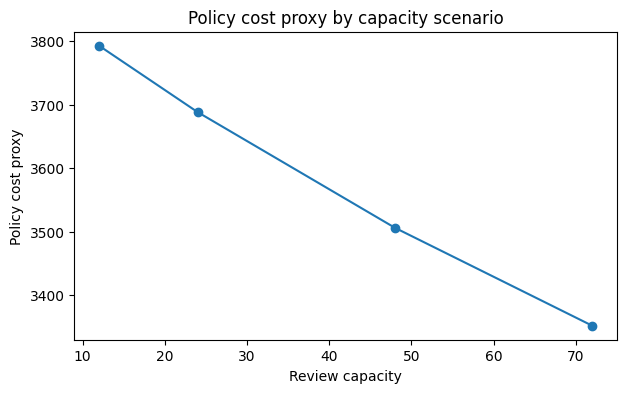

In [16]:
_, axis = plt.subplots(figsize=(7, 4))
axis.plot(
    capacity_table['review_capacity'],
    capacity_table['total_policy_cost_proxy'],
    marker='o',
)
axis.set_xlabel('Review capacity')
axis.set_ylabel('Policy cost proxy')
axis.set_title('Policy cost proxy by capacity scenario')
plt.show()

## Read the capacity tradeoff cautiously

The chart shows a policy proxy, not a measured financial result.

It is only useful if the ranked queue has real signal on unseen data. In this notebook, the later test results are weak, so this section should be read as an illustration of policy mechanics, not as evidence for a production inspection rule.

## Turn the ranked queue into a draft triage rule

The queue does not create fake severity labels.

It creates three actions only.

- **Inspect now** means the alert fits inside current review capacity.
- **Expedite next** means it sits just below the review line, falls inside the expedite band, and still clears the high risk cutoff.
- **Monitor** means it stays in backlog.

In this notebook, this triage logic is still a draft policy view. The held out test results do not support treating it as a validated operating rule yet.

In [17]:

triage_queue = risk_queue.copy()
triage_queue['action'] = 'Monitor'

triage_queue.loc[
    triage_queue['queue_rank'] <= review_capacity,
    'action',
] = 'Inspect now'

triage_queue.loc[
    (triage_queue['queue_rank'] > review_capacity)
    & (triage_queue['queue_rank'] <= review_capacity + expedite_slots)
    & triage_queue['is_high_risk'],
    'action',
] = 'Expedite next'

inspect_now_count = int((triage_queue['action'] == 'Inspect now').sum())
expedite_next_count = int((triage_queue['action'] == 'Expedite next').sum())
remaining_high_risk_backlog_count = int(
    ((triage_queue['action'] == 'Monitor') & triage_queue['is_high_risk']).sum()
)

triage_queue.head(20)


,alert_id,window_start,window_end,actual_failure_window,predicted_failure_probability,queue_rank,is_high_risk,action
0,6701,2020-07-19 12:00:00,2020-07-19 12:30:00,0,0.744,1,True,Inspect now
1,6209,2020-07-05 22:00:00,2020-07-05 22:30:00,0,0.688,2,True,Inspect now
2,6541,2020-07-16 01:00:00,2020-07-16 01:30:00,0,0.678,3,True,Inspect now
3,6208,2020-07-05 21:30:00,2020-07-05 22:00:00,0,0.626,4,True,Inspect now
4,6545,2020-07-16 03:00:00,2020-07-16 03:30:00,0,0.604,5,True,Inspect now
5,6543,2020-07-16 02:00:00,2020-07-16 02:30:00,0,0.589,6,True,Inspect now
6,6211,2020-07-05 23:00:00,2020-07-05 23:30:00,0,0.586,7,True,Inspect now
7,6102,2020-07-03 16:30:00,2020-07-03 17:00:00,0,0.573,8,True,Inspect now
8,6633,2020-07-18 02:00:00,2020-07-18 02:30:00,0,0.557,9,True,Inspect now
9,6630,2020-07-18 00:30:00,2020-07-18 01:00:00,0,0.533,10,True,Inspect now


## Final readout

This section closes the notebook with the quantities produced by the current setup.

These values should be read as outputs of an exploratory draft, not as a validated inspection policy. The later test period is the deciding check, and in this run the locked rule does not identify the actual positive windows at the chosen cutoff.

In [18]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)

current_capacity_row = capacity_table.loc[
    capacity_table["review_capacity"] == review_capacity
].iloc[0]

final_readout = pd.DataFrame(
    {
        "question": [
            "Selected model",
            "Operating high risk cutoff",
            "High risk windows",
            "Positive windows in high risk pool",
            "Today's review capacity",
            "Reviewed now",
            "Expedited next",
            "High risk backlog after today",
            "Deferred positive windows in test period",
        ],
        "answer": [
            selected_model_name,
            round(operating_high_risk_cutoff, 6),
            high_risk_alert_count,
            high_risk_positive_windows,
            review_capacity,
            inspect_now_count,
            expedite_next_count,
            remaining_high_risk_backlog_count,
            int(current_capacity_row["positive_windows_left_in_backlog"]),
        ],
    }
)

display(
    final_readout.style.set_properties(
        subset=["question"],
        **{"white-space": "normal"}
    )
)

,question,answer
0,Selected model,Random Forest
1,Operating high risk cutoff,0.515708
2,High risk windows,14
3,Positive windows in high risk pool,0
4,Today's review capacity,24
5,Reviewed now,24
6,Expedited next,0
7,High risk backlog after today,0
8,Deferred positive windows in test period,34


## Limits and next upgrades

This notebook is a queueing and review support draft for one compressor source. It is not a full maintenance optimizer.

What this notebook does well

- It respects time order instead of using a random split.
- It keeps the target definition explicit.
- It turns model scores into a ranked review queue.
- It separates model rule, capacity, and expedite policy.
- It avoids tuning the operating cutoff on the test period.

What the test period shows

- The validation winner weakens sharply on the held out test period.
- The locked high risk rule captures zero positive windows in the test high risk pool.
- That means the current triage rule is not trustworthy as written.

What needs improvement next

- Rebuild change features so they respect actual elapsed time between windows, or keep empty windows and impute.
- Evaluate by failure event, not only by window.
- Use rolling time folds or leave one failure out style validation where possible.
- Add event level checks such as whether the model flagged the 24 hour pre failure period at all, how early, and with how many false alerts per day.
- Revisit the target boundary and state clearly whether the exact failure start boundary is included.
- Calibrate probabilities only after the ranking shows useful unseen period signal.
- Replace policy cost proxies with real operating costs only after the ranking is credible.